<a href="https://colab.research.google.com/github/cedricguilmin/analytics_mining/blob/main/countries_ue_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skimpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
countries_ue = pd.read_csv('/content/drive/MyDrive/00_datamining/countries_ue.txt', sep = '\t')
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1


In [ ]:
features = ['PIB', 'Dep_pub', 'Rev_net', 'Esp_vie', 'Chomage', 'Education', 'Gini', 'Securite']
df = countries_ue[features]
X_stand = StandardScaler().fit_transform(df)

In [ ]:
pd.DataFrame(X_stand).head()

,0,1,2,3,4,5,6,7
0,0.592911,0.681869,0.787142,0.474790,-0.411808,0.835717,-0.765824,1.494862
1,-1.226396,-1.288193,-0.408723,-1.741317,0.044817,-0.426909,0.952939,-1.006473
2,-0.606919,-0.716139,-0.094022,-0.411653,-0.640121,-1.160047,-1.208535,-0.576756
3,1.231951,1.625564,2.024967,0.133850,-0.594458,0.767833,-0.687698,1.257556
4,0.449453,0.338416,0.031859,0.542978,-0.685783,0.061849,-0.062693,0.779737


<Axes: >

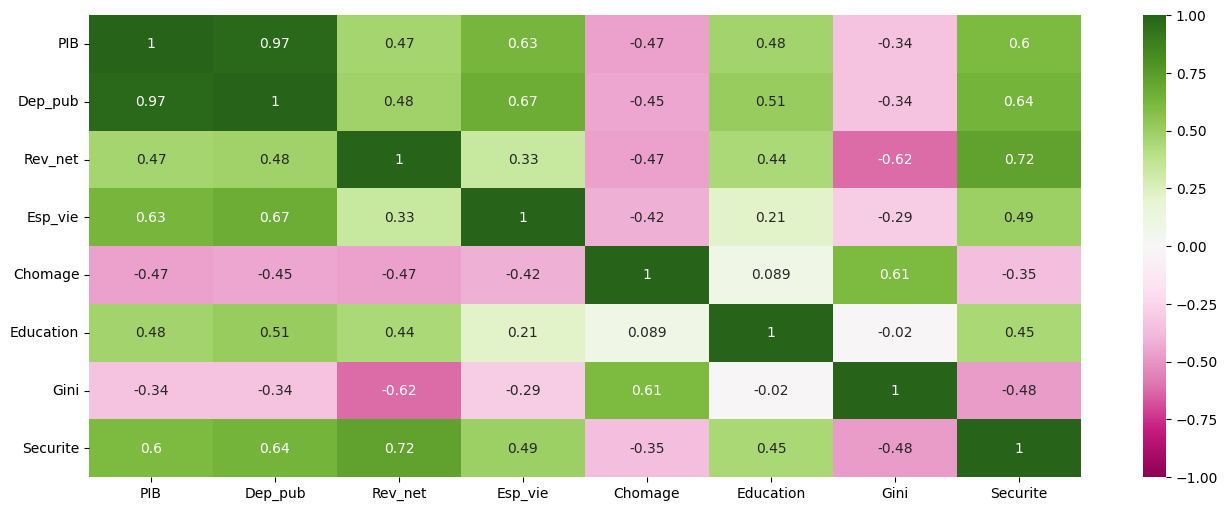

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr()
# interesting reading on how to set up the visuals of the correlation heatmap:
# https://medium.com/@szabo.bibor/how-to-create-a-seaborn-correlation-heatmap-in-python-834c0686b88e
plt.figure(figsize=(16, 6)) # control the size of the graphs that is going to be created
sns.heatmap(correlation_matrix, vmin = -1, vmax = 1, cmap="PiYG", annot = True)

In [ ]:
correlation_matrix

,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite
PIB,1.000000,0.971965,0.466848,0.630162,-0.466833,0.475289,-0.340483,0.602782
Dep_pub,0.971965,1.000000,0.479551,0.666026,-0.446887,0.511447,-0.340237,0.637336
Rev_net,0.466848,0.479551,1.000000,0.330917,-0.467497,0.440321,-0.619680,0.723586
Esp_vie,0.630162,0.666026,0.330917,1.000000,-0.415441,0.213664,-0.294010,0.494125
Chomage,-0.466833,-0.446887,-0.467497,-0.415441,1.000000,0.089003,0.609203,-0.354792
Education,0.475289,0.511447,0.440321,0.213664,0.089003,1.000000,-0.020282,0.448308
Gini,-0.340483,-0.340237,-0.619680,-0.294010,0.609203,-0.020282,1.000000,-0.478460
Securite,0.602782,0.637336,0.723586,0.494125,-0.354792,0.448308,-0.478460,1.000000


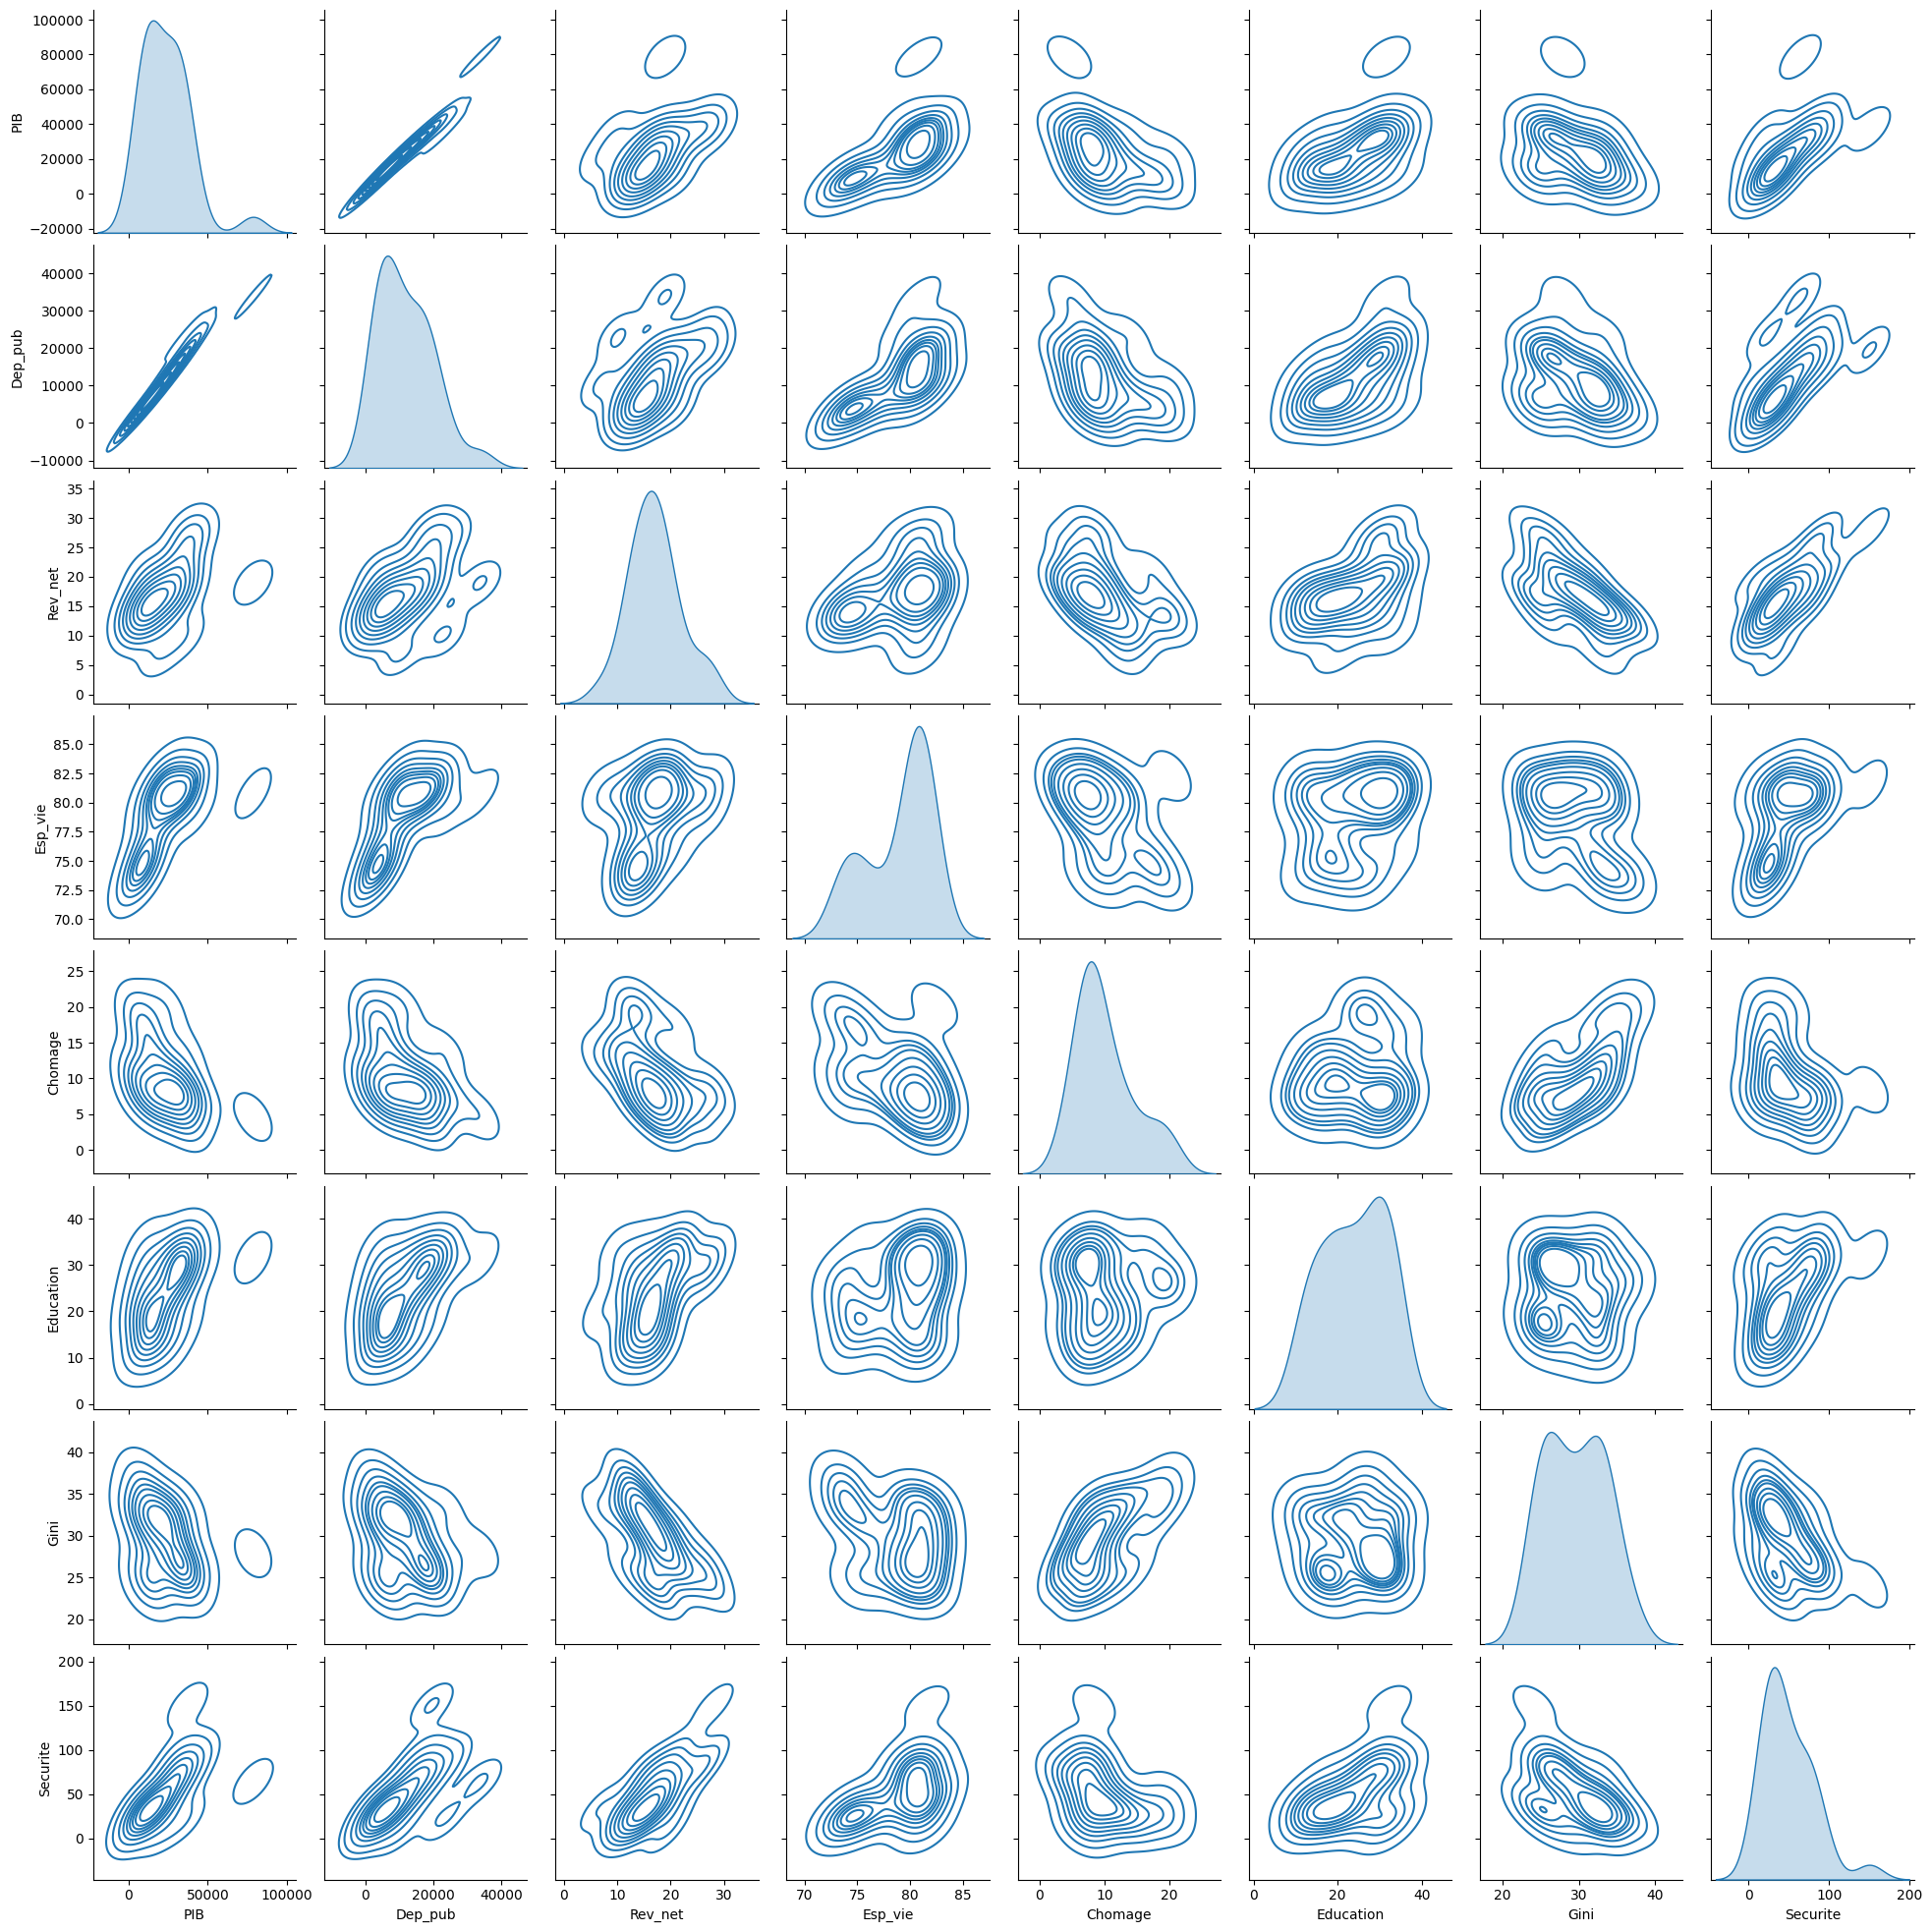

In [ ]:
sns.pairplot(df, kind="kde")

In [ ]:
type(correlation_matrix)

pandas.DataFrame

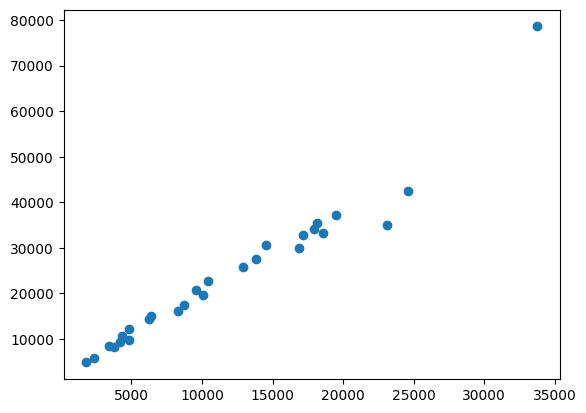

In [ ]:
plt.scatter(countries_ue['Dep_pub'], countries_ue['PIB'])

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)
pca.fit(X_stand)

PCA()

In [ ]:
dir(pca)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_fit',
 '_fit_full',
 '_fit_svd_solver',
 '_fit_truncated',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_n_features_out',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_transform',

In [ ]:
print(pca.explained_variance_ratio_)

[0.54151331 0.17290124 0.12356887 0.05894309 0.03964744 0.03850333
 0.02182165 0.00310107]


In [ ]:
pca.explained_variance_ratio_.sum()

np.float64(0.9999999999999999)

In [ ]:
# show how pca.explained_variance_ratio_ can be obtained
pca.explained_variance_ / pca.explained_variance_.sum()

array([0.54151331, 0.17290124, 0.12356887, 0.05894309, 0.03964744,
       0.03850333, 0.02182165, 0.00310107])

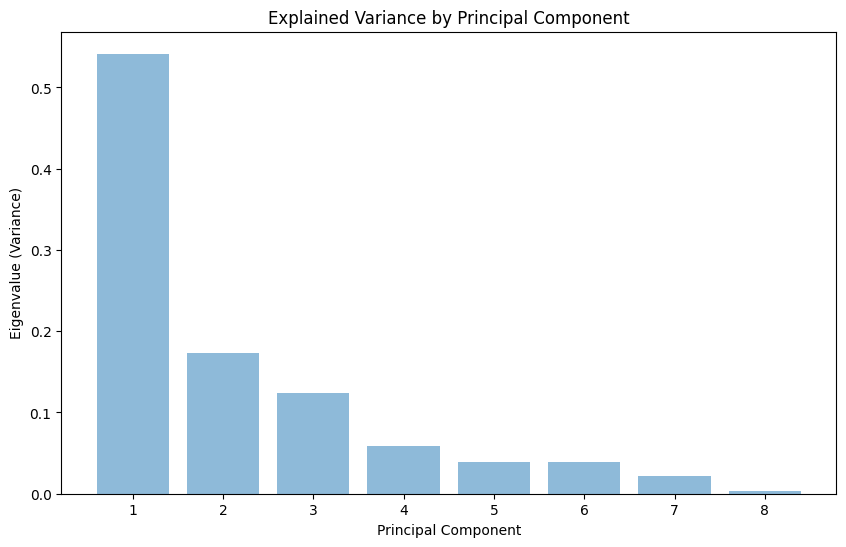

In [ ]:
# Visualize explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_,
        alpha=0.5)
plt.ylabel('Eigenvalue (Variance)')
plt.xlabel('Principal Component')
plt.title('Explained Variance by Principal Component')
plt.show()

In [ ]:
#find eigenvalues and eigenvectoers via numpy only
import numpy as np
# Create covariance matrix
cov_matrix = np.cov(X_stand.T)
# Get eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
print("Manual eigenvalues:", eigenvalues)

Manual eigenvalues: [4.49872598 1.43641027 1.02657213 0.48968103 0.32937876 0.31987384
 0.18128753 0.02576277]


In [ ]:
pca.explained_variance_

array([4.49872598, 1.43641027, 1.02657213, 0.48968103, 0.32937876,
       0.31987384, 0.18128753, 0.02576277])

In [ ]:
# there is direct mathematical relationship between singular value and explained_variance_
pca.singular_values_**2 / (X_stand.shape[0] - 1)

array([4.49872598, 1.43641027, 1.02657213, 0.48968103, 0.32937876,
       0.31987384, 0.18128753, 0.02576277])

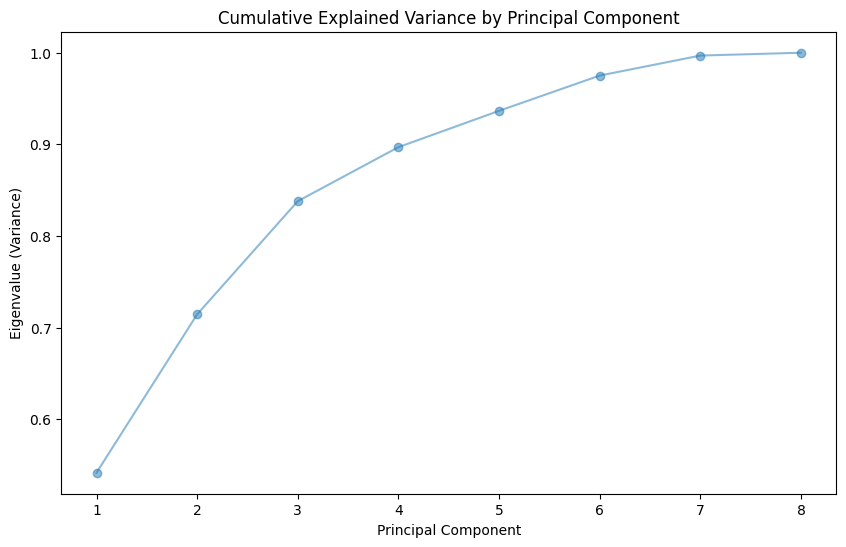

In [ ]:
# Visualize cumulative explained variance
explained_variance_ratio_cumulative = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio_cumulative)+1),
        explained_variance_ratio_cumulative, 'o-',
        alpha=0.5)
plt.ylabel('Eigenvalue (Variance)')
plt.xlabel('Principal Component')
plt.title('Cumulative Explained Variance by Principal Component')
plt.show()

In [ ]:
pca.components_.shape

(8, 8)

In [ ]:
features

['PIB',
 'Dep_pub',
 'Rev_net',
 'Esp_vie',
 'Chomage',
 'Education',
 'Gini',
 'Securite']

In [ ]:
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1


In [ ]:
X_stand

array([[ 0.59291118,  0.68186856,  0.78714194,  0.47478986, -0.41180814,
         0.83571651, -0.76582369,  1.49486236],
       [-1.22639633, -1.28819336, -0.40872326, -1.74131708,  0.0448169 ,
        -0.42690934,  0.9529393 , -1.00647256],
       [-0.60691886, -0.71613877, -0.09402189, -0.41165291, -0.64012067,
        -1.16004693, -1.20853536, -0.57675605],
       [ 1.2319511 ,  1.62556413,  2.02496733,  0.13385033, -0.59445816,
         0.7678334 , -0.6876981 ,  1.25755623],
       [ 0.44945324,  0.33841573,  0.03185866,  0.54297777, -0.68578317,
         0.06184906, -0.06269337,  0.77973712],
       [-0.84166822, -0.96091385,  0.80812204, -0.99125012,  1.55167956,
         1.39235802,  0.45814389, -0.4356551 ],
       [ 0.74288994,  1.43500296, -1.43674773,  0.71344754,  0.82107948,
         1.24301517,  0.9529393 , -0.85254426],
       [-0.26131564, -0.22614078, -2.12909075,  0.57707172,  0.56993571,
        -0.57625218,  0.87481371, -0.49658506],
       [-0.05264955, -0.18525963

In [ ]:
pca.components_

array([[ 0.41833364,  0.42604256,  0.36868605,  0.33858254, -0.29965404,
         0.24240575, -0.29762472,  0.39469431],
       [ 0.20308841,  0.22773941, -0.13377061,  0.04601552,  0.51833326,
         0.58391333,  0.52374712,  0.0542463 ],
       [-0.29508181, -0.27743151,  0.52186094, -0.4817719 ,  0.2173693 ,
         0.37545585, -0.2522695 ,  0.28223937],
       [-0.32707405, -0.240037  ,  0.080139  ,  0.65095178,  0.38661682,
        -0.24245766,  0.03635303,  0.44233981],
       [ 0.27021403,  0.22418931, -0.14818384, -0.4711095 ,  0.21956427,
        -0.50869335,  0.09278046,  0.56323647],
       [-0.1317047 , -0.13842426,  0.30048327, -0.04045691, -0.53133844,
        -0.03637618,  0.73552719,  0.21661398],
       [ 0.22238748,  0.13845799,  0.67417401,  0.03591112,  0.33793654,
        -0.3725816 ,  0.1498673 , -0.44731938],
       [-0.67073348,  0.73718638,  0.02560616, -0.05031428, -0.00927338,
        -0.04028236,  0.00885202, -0.04121427]])

In [ ]:
# get the data in the new space
X_new_space = pca.fit_transform(X_stand)
X_new_space.shape

(27, 8)

In [ ]:
X_new_space[0:10, ]

array([[ 2.13342772e+00,  1.46777932e-01,  6.57272271e-01,
         2.86105827e-01,  2.28126563e-01, -6.22861092e-03,
        -4.60003396e-01,  3.01126941e-03],
       [-2.59992029e+00, -3.49437892e-01,  6.69886123e-01,
        -7.45657879e-01,  9.26675919e-03,  7.62086295e-01,
        -2.19461490e-02,  1.67915519e-02],
       [-6.90382853e-01, -1.96613276e+00,  9.44310025e-02,
        -1.70369044e-01, -1.04100501e-01, -4.64058013e-01,
        -1.95301300e-02, -3.68043631e-02],
       [ 3.06510795e+00,  2.03936684e-01,  8.65244684e-01,
        -4.28453136e-01,  4.57582031e-01,  2.70293628e-01,
         7.16467445e-01,  3.33815647e-01],
       [ 1.07469671e+00, -1.20814366e-01, -3.61436784e-01,
         1.90267262e-01,  1.88118814e-01,  3.66488153e-01,
        -4.25195869e-01, -1.07314789e-01],
       [-1.23492198e+00,  1.29013552e+00,  2.03575425e+00,
         1.17136654e-02, -6.66080370e-01, -1.05711840e-01,
         4.58135295e-01, -1.21736688e-01],
       [ 6.91618044e-02,  2.306961

In [ ]:
# Stick them side by side
pc_names = [f'PC_{i+1}' for i in range(pca.n_components_)]
countries_pca = pd.concat([countries_ue, pd.DataFrame(X_new_space, columns=pc_names)], axis=1)
countries_pca.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,...,Localisation,Rating,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,...,Ouest,2,2.133428,0.146778,0.657272,0.286106,0.228127,-0.006229,-0.460003,0.003011
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,...,Est,4,-2.599920,-0.349438,0.669886,-0.745658,0.009267,0.762086,-0.021946,0.016792
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,...,Est,3,-0.690383,-1.966133,0.094431,-0.170369,-0.104101,-0.464058,-0.019530,-0.036804
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,...,Nord,1,3.065108,0.203937,0.865245,-0.428453,0.457582,0.270294,0.716467,0.333816
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,...,Ouest,1,1.074697,-0.120814,-0.361437,0.190267,0.188119,0.366488,-0.425196,-0.107315


In [ ]:
print(countries_pca.dtypes)

Pays                str
PIB             float64
Dep_pub         float64
Rev_net         float64
Esp_vie         float64
Chomage         float64
Education       float64
Gini            float64
Securite        float64
Adhesion          int64
OCDE                str
Localisation        str
Rating            int64
PC_1            float64
PC_2            float64
PC_3            float64
PC_4            float64
PC_5            float64
PC_6            float64
PC_7            float64
PC_8            float64
dtype: object


In [ ]:
from skimpy import skim
skim(countries_pca)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27     │ │ float64     │ 16    │                                                          │
│ │ Number of columns │ 21     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column     ┃ NA  ┃ NA % ┃ mean       ┃ sd     ┃ p0      ┃ p25      ┃ p50       ┃ p75     ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │    PIB     │   0 │    0 │      23610 │  15630 │    4800 │    11400 │     20700 │   33000 │  78600 │ █▄▆▁ ▁ │  │
│ │  Dep_pub   │   0 │    0 │      11860 │   7964 │    1791 │     4826 │     10090 │   17570 │  33740 │ █▄▄▄▁▁ │  │
│ │  Rev_net   │   0 │    0 │      17.05 │  4.857 │     6.9 │    13.75 │      16.6 │    19.1 │     28 │ ▂▅██▁▃ │  │
│ │  Esp_vie   │   0 │    0 │      78.91 │  2.989 │    73.5 │     76.2 │      80.3 │      81 │   82.3 │ ▄▃▁▁█▇ │  │
│ │  Chomage   │   0 │    0 │       10.1 │  4.463 │     4.4 │      7.3 │       8.4 │    12.3 │   20.1 │ ▄█▃▂▁▂ │  │
│ │ Education  │   0 │    0 │      23.84 │  7.506 │    11.9 │    18.25 │      24.4 │   30.45 │   34.1 │ ▆▃▅▅▅█ │  │
│ │    Gini    │   0 │    0 │      29.54 │  3.913 │    23.8 │       26 │      29.3 │    33.1 │   36.9 │ █▅▅▃█▂ │  │
│ │  Securite  │   0 │    0 │      49.69 │  31.78 │     8.7 │       27 │        40 │    72.3 │  150.5 │ █▆▅▂ ▁ │  │
│ │  Adhesion  │   0 │    0 │       1987 │  19.52 │    1957 │     1973 │      1995 │    2004 │   2007 │ ▄▂▁▁▂█ │  │
│ │   Rating   │   0 │    0 │      2.519 │  1.369 │       1 │        1 │         3 │       3 │      5 │ █▄ ▇▃▃ │  │
│ │    PC_1    │   0 │    0 │ -1.316e-16 │  2.121 │  -3.228 │   -1.574 │   0.01655 │   1.337 │  4.042 │ ▇██▅▄▄ │  │
│ │    PC_2    │   0 │    0 │  6.579e-17 │  1.199 │  -1.966 │  -0.8849 │   -0.1208 │  0.8516 │  2.307 │ ▇▃█▅▃▅ │  │
│ │    PC_3    │   0 │    0 │ -8.532e-17 │  1.013 │  -1.703 │  -0.6997 │   0.09443 │  0.7676 │  2.036 │ ▇▄██▇▃ │  │
│ │    PC_4    │   0 │    0 │  -6.99e-17 │ 0.6998 │  -1.939 │  -0.3899 │   -0.1091 │  0.3651 │  1.654 │ ▁▂██▄▂ │  │
│ │    PC_5    │   0 │    0 │  3.084e-17 │ 0.5739 │  -2.024 │  -0.3108 │    0.1421 │   0.444 │ 0.7084 │ ▁ ▁▆▆█ │  │
│ │    PC_6    │   0 │    0 │  8.224e-18 │ 0.5656 │  -1.451 │  -0.3441 │   0.06626 │  0.3596 │  1.015 │ ▁▃▄▅█▃ │  │
│ │    PC_7    │   0 │    0 │  8.224e-18 │ 0.4258 │   -1.09 │  -0.2433 │ -0.001553 │  0.2902 │ 0.7775 │ ▁▁█▄▇▃ │  │
│ │    PC_8    │   0 │    0 │ -2.262e-17 │ 0.1605 │ -0.4175 │ -0.07699 │  -0.01584 │ 0.03893 │ 0.4728 │ ▁▁█▄ ▁ │  │
│ └────────────┴─────┴──────┴────────────┴────────┴─────────┴──────────┴───────────┴─────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃             ┃    ┃      ┃          ┃          ┃     

In [ ]:
# Select columns starting with 'PC_'
pc_cols = countries_pca[pc_names]

# Compute mean and variance
means = pc_cols.mean()
variances = pc_cols.var()

print("Means:\n", means)
print("Variances:\n", variances)

Means:
 PC_1   -1.315820e-16
PC_2    6.579099e-17
PC_3   -8.532270e-17
PC_4   -6.990293e-17
PC_5    3.083953e-17
PC_6    8.223874e-18
PC_7    8.223874e-18
PC_8   -2.261565e-17
dtype: float64
Variances:
 PC_1    4.498726
PC_2    1.436410
PC_3    1.026572
PC_4    0.489681
PC_5    0.329379
PC_6    0.319874
PC_7    0.181288
PC_8    0.025763
dtype: float64


In [ ]:
all_relevant_cols = features + pc_names
print(all_relevant_cols)

['PIB', 'Dep_pub', 'Rev_net', 'Esp_vie', 'Chomage', 'Education', 'Gini', 'Securite', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8']


In [ ]:
correlation_matrix_pca = countries_pca[all_relevant_cols].corr()

In [ ]:
correlation_matrix_pca.loc[features, pc_names].head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
PIB,0.870708,0.238852,-0.293388,-0.224599,0.152181,-0.073096,0.092918,-0.105646
Dep_pub,0.886753,0.267844,-0.275839,-0.164831,0.126260,-0.076826,0.057850,0.116112
Rev_net,0.767373,-0.157328,0.518865,0.055031,-0.083455,0.166769,0.281683,0.004033
Esp_vie,0.704716,0.054119,-0.479006,0.447003,-0.265323,-0.022454,0.015004,-0.007925
Chomage,-0.623691,0.609611,0.216121,0.265486,0.123656,-0.294894,0.141196,-0.001461


<Axes: >

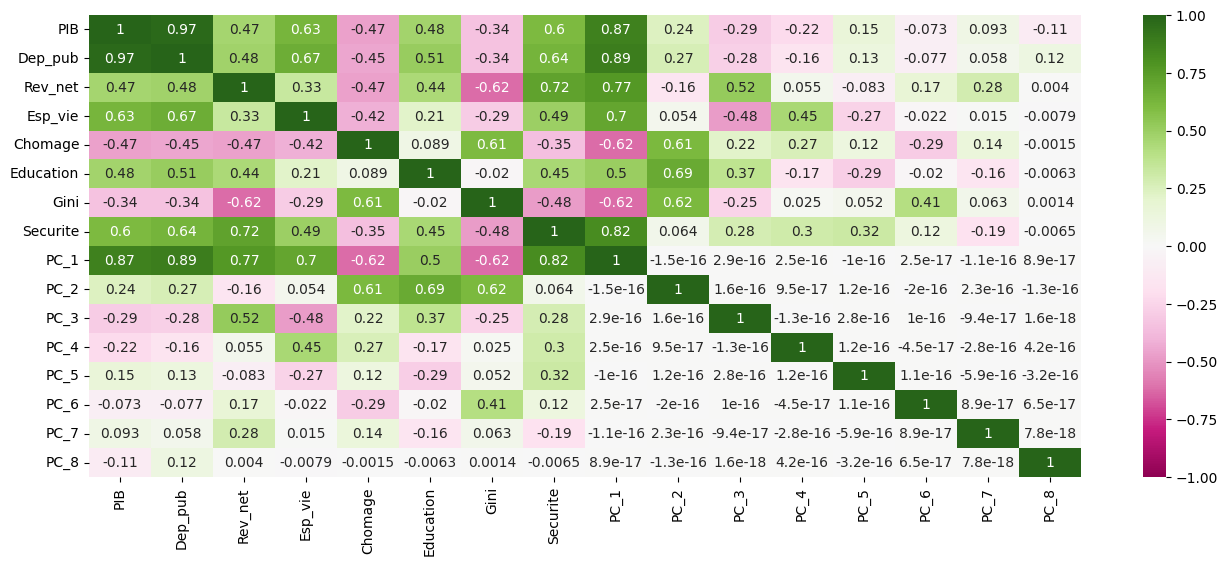

In [ ]:
plt.figure(figsize=(16, 6)) # control the size of the graphs that is going to be created
sns.heatmap(correlation_matrix_pca, vmin = -1, vmax = 1, cmap="PiYG", annot = True)

In [ ]:
def plot_pc(x, y):
  # Select the first two principal components
  pc1_name = pc_names[x]
  pc2_name = pc_names[y]
  pc1 = countries_pca[pc1_name]
  pc2 = countries_pca[pc2_name]

  plt.figure(figsize=(8,8))
  plt.title('PCA Correlation Circle')
  plt.xlabel(pc1_name)
  plt.ylabel(pc2_name)

  # Draw unit circle
  circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
  plt.gca().add_artist(circle)

  for feature in features:
      # Correlation of each feature with PC1 and PC2
      corr_pc1 = countries_pca[feature].corr(pc1)
      corr_pc2 = countries_pca[feature].corr(pc2)
      # Plot arrow and label
      plt.arrow(0, 0, corr_pc1, corr_pc2,
                color='b', alpha=0.7, head_width=0.03, length_includes_head=True)
      plt.text(corr_pc1*1.15, corr_pc2*1.15, feature, color='r', ha='center', va='center')

  plt.xlim(-1.1, 1.1)
  plt.ylim(-1.1, 1.1)
  plt.grid(True)
  plt.axhline(0, color='black', lw=0.5)
  plt.axvline(0, color='black', lw=0.5)
  plt.show()

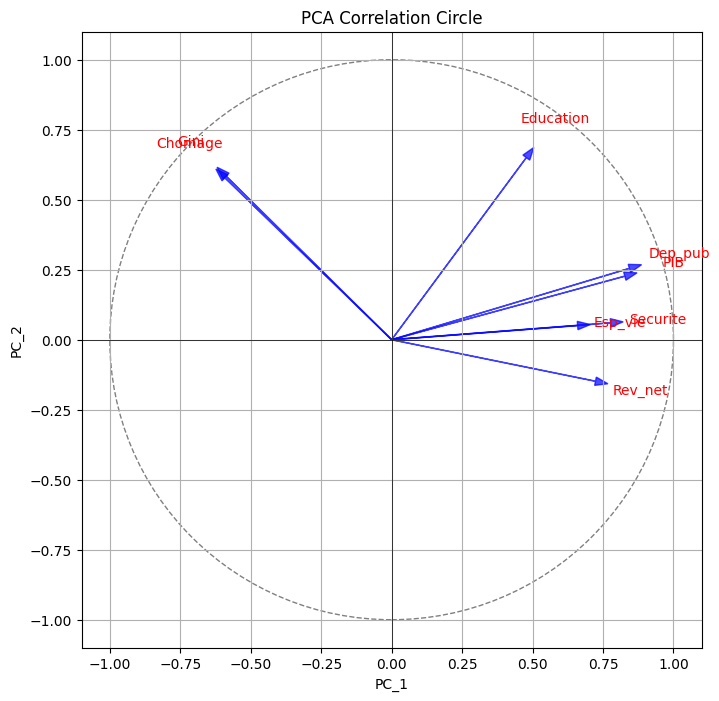

In [ ]:
plot_pc(0, 1)

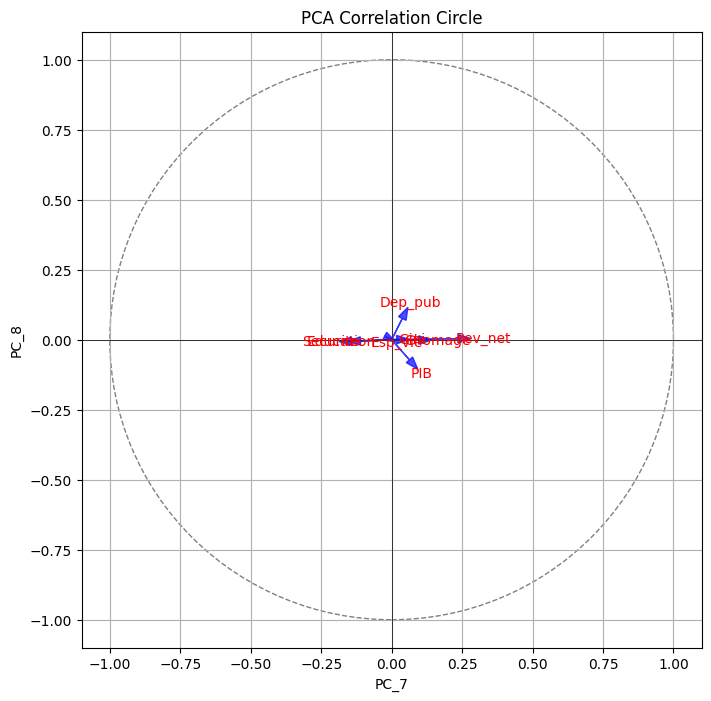

In [ ]:
plot_pc(6, 7)

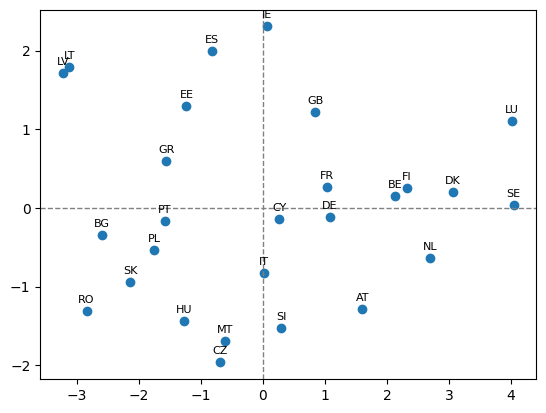

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
xs = countries_pca.PC_1
ys = countries_pca.PC_2
label = countries_pca.Pays

plt.scatter(xs, ys)

# Add a label next to each point
for x, y, z in zip(xs, ys, label):
    plt.annotate(
        z,           # The label text
        (x, y),          # The point to label
        textcoords="offset points", # Position relative to the point
        xytext=(0, 6),  # Offset label 10 points above the point
        ha='center',      # Center alignment
        fontsize=8
    )
# Add vertical line at x=0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Add horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.show()

In [ ]:
pc_names

['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8']

In [ ]:
from sklearn.cluster import KMeans
countries_pca['cluster_4_kmeans'] = KMeans(n_clusters=4, random_state=10, init='k-means++').fit_predict(countries_pca[pc_names[0:5]])

In [ ]:
countries_pca.groupby('cluster_4_kmeans').size()

cluster_4_kmeans
0     5
1    10
2     3
3     9
dtype: int64

In [ ]:
import matplotlib.patches as mpatches
color_map = {0: 'red', 1: 'green', 2: 'blue', 3 : 'yellow'}
colors = [color_map[cat] for cat in countries_pca['cluster_4_kmeans']]

In [ ]:
colors

['green',
 'yellow',
 'yellow',
 'green',
 'green',
 'blue',
 'red',
 'red',
 'red',
 'green',
 'red',
 'yellow',
 'blue',
 'blue',
 'green',
 'yellow',
 'yellow',
 'green',
 'green',
 'yellow',
 'red',
 'yellow',
 'yellow',
 'yellow',
 'green',
 'green',
 'green']

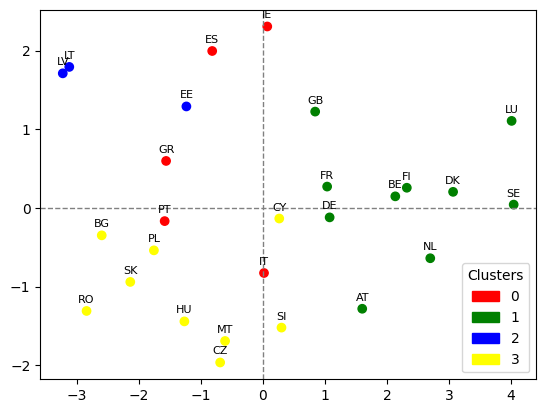

In [ ]:
# Example data
xs = countries_pca.PC_1
ys = countries_pca.PC_2
label = countries_pca.Pays

plt.scatter(xs, ys, c=colors)

# Add a label next to each point
for x, y, z in zip(xs, ys, label):
    plt.annotate(
        z,           # The label text
        (x, y),          # The point to label
        textcoords="offset points", # Position relative to the point
        xytext=(0, 6),  # Offset label 10 points above the point
        ha='center',      # Center alignment
        fontsize=8
    )
# Add vertical line at x=0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
# Add horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
# Create legend
patches = [mpatches.Patch(color=color, label=cat)
           for cat, color in color_map.items()]
plt.legend(handles=patches, title='Clusters', loc = 'lower right')
plt.show()

In [ ]:
## Everything below has not been covered in class
pc_names_2 = [p + '_2' for p in pc_names]
print(pc_names_2)

NameError: name 'pc_names' is not defined

In [ ]:
countries_pca_pc_2 = pd.DataFrame(index=countries_pca.index)
for pc, pc_2 in zip(pc_names,pc_names_2):
  countries_pca_pc_2[pc_2] = countries_pca[pc]**2

NameError: name 'pd' is not defined

In [ ]:
countries_pca_pc_2.head()

,PC_1_2,PC_2_2,PC_3_2,PC_4_2,PC_5_2,PC_6_2,PC_7_2,PC_8_2
0,4.551514,0.021544,0.432007,0.081857,0.052042,0.000039,0.211603,0.000009
1,6.759586,0.122107,0.448747,0.556006,0.000086,0.580776,0.000482,0.000282
2,0.476628,3.865678,0.008917,0.029026,0.010837,0.215350,0.000381,0.001355
3,9.394887,0.041590,0.748648,0.183572,0.209381,0.073059,0.513326,0.111433
4,1.154973,0.014596,0.130637,0.036202,0.035389,0.134314,0.180792,0.011516


In [ ]:
countries_pca_pc_2['total_variance'] = countries_pca_pc_2[pc_names_2].sum(axis=1)
countries_pca_pc_2.head()

,PC_1_2,PC_2_2,PC_3_2,PC_4_2,PC_5_2,PC_6_2,PC_7_2,PC_8_2,total_variance
0,4.551514,0.021544,0.432007,0.081857,0.052042,0.000039,0.211603,0.000009,5.350614
1,6.759586,0.122107,0.448747,0.556006,0.000086,0.580776,0.000482,0.000282,8.468070
2,0.476628,3.865678,0.008917,0.029026,0.010837,0.215350,0.000381,0.001355,4.608172
3,9.394887,0.041590,0.748648,0.183572,0.209381,0.073059,0.513326,0.111433,11.275896
4,1.154973,0.014596,0.130637,0.036202,0.035389,0.134314,0.180792,0.011516,1.698418


In [ ]:
quality_names = [p + '_quality' for p in pc_names]
print(quality_names)

['PC_1_quality', 'PC_2_quality', 'PC_3_quality', 'PC_4_quality', 'PC_5_quality', 'PC_6_quality', 'PC_7_quality', 'PC_8_quality']


In [ ]:
for pc_2, quality in zip(pc_names_2, quality_names):
  countries_pca_pc_2[quality] = countries_pca_pc_2[pc_2] / countries_pca_pc_2['total_variance']

NameError: name 'pc_names_2' is not defined

In [ ]:
# check that each PC_X_quality sums to 1
countries_pca_pc_2[quality_names].sum(axis=1).head()

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [ ]:
for i, cumul_quality in enumerate(quality_names):
  print(quality_names[:i+1])
  countries_pca_pc_2[quality_names[i] + '_cumul'] = countries_pca_pc_2[quality_names[:i+1]].sum(axis=1)

NameError: name 'quality_names' is not defined

In [ ]:
countries_pca_pc_2.head()

,PC_1_2,PC_2_2,PC_3_2,PC_4_2,PC_5_2,PC_6_2,PC_7_2,PC_8_2,total_variance,PC_1_quality,...,PC_7_quality,PC_8_quality,PC_1_quality_cumul,PC_2_quality_cumul,PC_3_quality_cumul,PC_4_quality_cumul,PC_5_quality_cumul,PC_6_quality_cumul,PC_7_quality_cumul,PC_8_quality_cumul
0,4.551514,0.021544,0.432007,0.081857,0.052042,0.000039,0.211603,0.000009,5.350614,0.850653,...,0.039547,0.000002,0.850653,0.854679,0.935419,0.950717,0.960444,0.960451,0.999998,1.0
1,6.759586,0.122107,0.448747,0.556006,0.000086,0.580776,0.000482,0.000282,8.468070,0.798244,...,0.000057,0.000033,0.798244,0.812664,0.865656,0.931316,0.931326,0.999910,0.999967,1.0
2,0.476628,3.865678,0.008917,0.029026,0.010837,0.215350,0.000381,0.001355,4.608172,0.103431,...,0.000083,0.000294,0.103431,0.942306,0.944241,0.950539,0.952891,0.999623,0.999706,1.0
3,9.394887,0.041590,0.748648,0.183572,0.209381,0.073059,0.513326,0.111433,11.275896,0.833183,...,0.045524,0.009882,0.833183,0.836872,0.903265,0.919545,0.938114,0.944593,0.990118,1.0
4,1.154973,0.014596,0.130637,0.036202,0.035389,0.134314,0.180792,0.011516,1.698418,0.680029,...,0.106447,0.006781,0.680029,0.688623,0.765539,0.786854,0.807691,0.886772,0.993219,1.0


In [ ]:
cols_to_keep = [col for col in countries_pca_pc_2.columns if col.endswith('_quality_cumul')]
countries_pca2 = pd.concat([countries_pca, countries_pca_pc_2[cols_to_keep]], axis=1)

NameError: name 'countries_pca_pc_2' is not defined

In [ ]:
countries_pca2

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,...,PC_8,cluster_4_kmeans,PC_1_quality_cumul,PC_2_quality_cumul,PC_3_quality_cumul,PC_4_quality_cumul,PC_5_quality_cumul,PC_6_quality_cumul,PC_7_quality_cumul,PC_8_quality_cumul
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,...,0.003011,1,0.850653,0.854679,0.935419,0.950717,0.960444,0.960451,0.999998,1.0
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,...,0.016792,3,0.798244,0.812664,0.865656,0.931316,0.931326,0.999910,0.999967,1.0
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,...,-0.036804,3,0.103431,0.942306,0.944241,0.950539,0.952891,0.999623,0.999706,1.0
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,...,0.333816,1,0.833183,0.836872,0.903265,0.919545,0.938114,0.944593,0.990118,1.0
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,...,-0.107315,1,0.680029,0.688623,0.765539,0.786854,0.807691,0.886772,0.993219,1.0
5,EE,10700.0,4348.6,20.9,76.0,16.9,34.1,31.3,36.1,2004,...,-0.121737,2,0.190309,0.398016,0.915182,0.915199,0.970564,0.971959,0.998151,1.0
6,IE,35000.0,23073.5,10.2,81.0,13.7,33.0,33.2,23.1,1973,...,0.472784,0,0.000529,0.589348,0.854014,0.889278,0.911143,0.968866,0.975270,1.0
7,GR,19600.0,10091.1,6.9,80.6,12.6,19.6,32.9,34.2,1981,...,-0.028850,0,0.366696,0.420252,0.855877,0.896042,0.899075,0.916793,0.999875,1.0
8,ES,22800.0,10410.6,14.9,82.3,20.1,25.8,33.9,50.8,1986,...,-0.194278,0,0.082285,0.570862,0.591096,0.926705,0.926926,0.961302,0.995367,1.0
9,FR,29900.0,16901.1,18.8,81.9,9.7,24.4,29.8,56.1,1957,...,0.148440,1,0.587437,0.627703,0.794058,0.902294,0.927923,0.930333,0.987905,1.0
